Using device: cuda
[INFO] Did not find data/pizza_steak_sushi, creating one...
[INFO] Downloading pizza_steak_sushi.zip from https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip...
[INFO] Download status: 200
[INFO] Unzipping pizza_steak_sushi.zip...
[INFO] Data prepared at data/pizza_steak_sushi
Automatic transforms:
ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)
Classes: ['pizza', 'steak', 'sushi']


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 33.8MB/s]



Epoch 1/5
----------
train Loss: 0.6886 Acc: 0.6933
val Loss: 0.2602 Acc: 0.9067

Epoch 2/5
----------
train Loss: 0.0732 Acc: 1.0000
val Loss: 0.3303 Acc: 0.8667

Epoch 3/5
----------
train Loss: 0.0393 Acc: 0.9911
val Loss: 0.3233 Acc: 0.9067

Epoch 4/5
----------
train Loss: 0.0454 Acc: 0.9778
val Loss: 0.2762 Acc: 0.8933

Epoch 5/5
----------
train Loss: 0.1145 Acc: 0.9733
val Loss: 0.2882 Acc: 0.9067

Training complete in 0m 15s
Best val Acc: 0.906667
Model saved to pizza_steak_sushi_efficientnet.pth

--- Running Inference on Test Images ---
Predicting for: data/pizza_steak_sushi/test/sushi/1245193.jpg


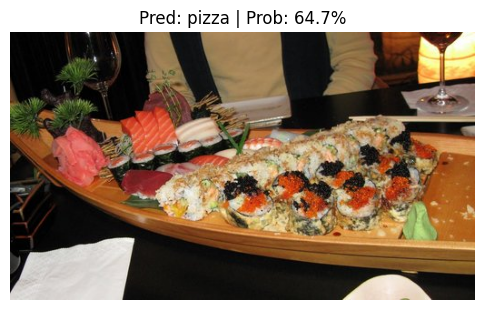

Predicting for: data/pizza_steak_sushi/test/pizza/2003290.jpg


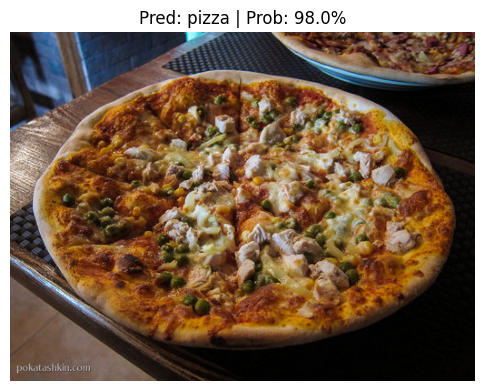

Predicting for: data/pizza_steak_sushi/test/pizza/344397.jpg


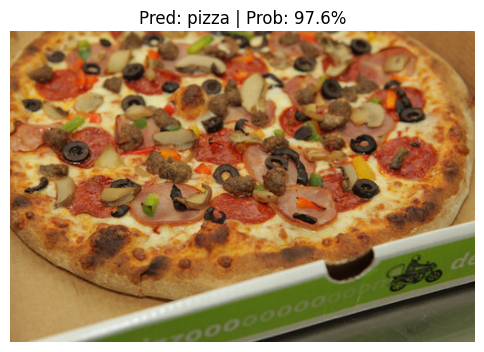

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
import os
import time
import copy
import requests
import zipfile
from pathlib import Path
import matplotlib.pyplot as plt
import random
from PIL import Image


# --- 0. 설정 및 장치 (Device Setup) ---
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps") # Mac Apple Silicon 지원
    else:
        return torch.device("cpu")


device = get_device()
print(f"Using device: {device}")




# --- 1. 데이터 준비 (Data Download & Setup) ---
def download_data(source_url, dest_dir):
    data_path = Path(dest_dir)
    image_path = data_path / "pizza_steak_sushi"
   
    if image_path.is_dir():
        print(f"[INFO] {image_path} directory exists, skipping download.")
    else:
        print(f"[INFO] Did not find {image_path}, creating one...")
        image_path.mkdir(parents=True, exist_ok=True)
       
        target_file = Path(source_url).name
        zip_path = data_path / target_file
       
        # 다운로드
        print(f"[INFO] Downloading {target_file} from {source_url}...")
        with open(zip_path, "wb") as f:
            request = requests.get(source_url)
            print(f"[INFO] Download status: {request.status_code}")
            f.write(request.content)
           
        # 압축 해제
        print(f"[INFO] Unzipping {target_file}...")
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(image_path)
           
        # zip 파일 삭제 (선택사항)
        os.remove(zip_path)
        print(f"[INFO] Data prepared at {image_path}")
   
    return image_path


# 실제 데이터셋 다운로드 (Github 원본 소스 활용)
data_root = "data"
source = "https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip"
image_path = download_data(source, data_root)


# 경로 설정
train_dir = image_path / "train"
test_dir = image_path / "test"




# --- 2. 사전 학습 모델에 맞는 Transform 및 DataLoader 구성 ---
# EfficientNet-B0 가중치 및 자동 전처리
weights = models.EfficientNet_B0_Weights.DEFAULT
auto_transforms = weights.transforms()


print(f"Automatic transforms:\n{auto_transforms}")


# 데이터셋 생성
train_data = datasets.ImageFolder(train_dir, transform=auto_transforms)
test_data = datasets.ImageFolder(test_dir, transform=auto_transforms)


class_names = train_data.classes
print(f"Classes: {class_names}")


# DataLoader 생성 (Windows/Mac 환경 호환성을 위해 num_workers 설정 주의)
# os.cpu_count()를 사용하되 최대 4로 제한, 오류 방지를 위해 0으로 설정할 수도 있음
NUM_WORKERS = 0 # 0은 메인 프로세스에서만 로드 (가장 안전함), 필요시 2~4로 변경 가능


dataloaders = {
    'train': DataLoader(train_data, batch_size=32, shuffle=True, num_workers=NUM_WORKERS),
    'val': DataLoader(test_data, batch_size=32, shuffle=False, num_workers=NUM_WORKERS)
}
dataset_sizes = {'train': len(train_data), 'val': len(test_data)}




# --- 3. 모델 로드 및 수정 ---
model_ft = models.efficientnet_b0(weights=weights)


# 분류기(classifier) 교체
# EfficientNet의 classifier는 Sequential 구조이므로 마지막 층(인덱스 1)을 교체
num_ftrs = model_ft.classifier[1].in_features
model_ft.classifier[1] = nn.Linear(num_ftrs, len(class_names))


model_ft = model_ft.to(device)




# --- 4. 손실 함수 및 옵티마이저 정의 ---
criterion = nn.CrossEntropyLoss()
optimizer_ft = optim.Adam(model_ft.parameters(), lr=0.001)
exp_lr_scheduler = optim.lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)




# --- 5. 학습 함수 정의 ---
def train_model(model, criterion, optimizer, scheduler, num_epochs=5):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
   
    # 결과 기록용
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}


    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 10)


        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()


            running_loss = 0.0
            running_corrects = 0


            # 배치 반복
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)


                optimizer.zero_grad()


                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)


                    # Backward + Optimize
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()


                # 통계 계산
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)


            if phase == 'train':
                scheduler.step()


            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
           
            # 기록 저장
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())


            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')


            # Best Model 저장
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())


    time_elapsed = time.time() - since
    print(f'\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')


    model.load_state_dict(best_model_wts)
    return model, history




# --- 6. 추론(Inference) 및 시각화 함수 ---
def predict_and_plot_image(model, image_path, class_names):
    """
    임의의 이미지 경로를 받아 모델로 예측하고 결과를 시각화합니다.
    """
    # 1. 이미지 로드 및 전처리
    img = Image.open(image_path)
   
    # 모델 학습시 사용한 transform과 동일하게 적용 (배치 차원 추가 필요)
    img_transformed = auto_transforms(img).unsqueeze(0).to(device)
   
    # 2. 예측
    model.eval()
    with torch.no_grad():
        outputs = model(img_transformed)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        max_prob, preds = torch.max(probs, 1)
        pred_class = class_names[preds.item()]
       
    # 3. 시각화
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Pred: {pred_class} | Prob: {max_prob.item()*100:.1f}%")
    plt.axis(False)
    plt.show()


# --- 실행 블록 ---
if __name__ == '__main__':
    # 1. 모델 학습 실행 (시간 절약을 위해 epoch 5회로 설정)
    model_ft, history = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=5)
   
    # 2. 모델 저장
    save_path = 'pizza_steak_sushi_efficientnet.pth'
    torch.save(model_ft.state_dict(), save_path)
    print(f"Model saved to {save_path}")


    # 3. 추론 테스트 (Test 폴더의 랜덤 이미지 3장 예측)
    print("\n--- Running Inference on Test Images ---")
    test_image_paths = list(Path(test_dir).glob("*/*.jpg"))
    random_image_paths = random.sample(test_image_paths, k=3)


    for img_path in random_image_paths:
        print(f"Predicting for: {img_path}")
        predict_and_plot_image(model_ft, img_path, class_names)
